### Example of coalition of the *Airport* in the construction of a new runway.

In [ ]:
import os
import sys
import math
import pandas as pd
import shap


file_root_shapley = os.path.join(
    "..", "..", "data", "exact", "shapley_cost_value_of_airport.csv"
)
file_root_grabisch = os.path.join(
    "..", "..", "data", "exact", "grabisch_of_airport.csv"
)
original = pd.read_csv(os.path.join(
    "..", "..", "data", "input", "airport.csv"
), sep=";").set_index(
    "label",
    verify_integrity=True
)

shapley_only = pd.read_csv(
    file_root_shapley,
    sep=";",
    header=None,
    names=["value"]
)
shapley_only = shapley_only.set_index(
    original.index.values,
    verify_integrity=True
)

psi_1 = original.join(shapley_only)

r_1 = pd.read_csv(
    file_root_grabisch,
    sep=";",
    header=0
).set_index(
    original.index.values,
    verify_integrity=True
)
r_1.columns = original.index.values

### Truncated characteristic values

In [10]:
from cgt_perezsechi.manipulation.norm import normalize_psi, normalize_r


n = 4
psi_1_truncated = psi_1.copy()
psi_1_truncated["value"] = psi_1_truncated["value"].astype(float).apply(lambda number: math.floor(number * 10 ** n) / 10 ** n)

r_1_truncated = r_1.astype(float).apply(lambda row: row.apply(lambda number: math.floor(number * 10 ** n) / 10 ** n))

psi_2 = normalize_psi(psi_1)
psi_2_truncated = psi_2.copy()
psi_2_truncated["value"] = psi_2_truncated["value"].astype(float).apply(lambda number: math.floor(number * 10 ** n) / 10 ** n)

r_2 = normalize_r(r_1)
r_2_truncated = r_2.astype(float).apply(lambda row: row.apply(lambda number: math.floor(number * 10 ** n) / 10 ** n))

/home/secci/Localspace/UCM/thesis/thesis-python/.venv/lib/python3.10/site-packages/cgt_perezsechi/manipulation/norm.py:8: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  max_edge_width = r.applymap(lambda x: abs(x)).max().max()
/home/secci/Localspace/UCM/thesis/thesis-python/.venv/lib/python3.10/site-packages/cgt_perezsechi/manipulation/norm.py:9: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  r = r.copy().applymap(lambda x: x / max_edge_width)


#### Cost Allocation Results

The Shapley values for this game are calculated in the file ./data/exact/shapley_cost_value_of_airport.csv. In the table below we represent these values:

In [11]:
psi_1_truncated

,plane,cost,value
label,,,
SM1,Small 1,100,-10.0
SM2,Small 2,100,-10.0
SM3,Small 3,100,-10.0
SM4,Small 4,100,-10.0
SM5,Small 5,100,-10.0
MD1,Medium 1,150,-20.0
MD2,Medium 2,150,-20.0
MD3,Medium 3,150,-20.0
LG1,Large 1,200,-45.0


In [12]:
psi_2_truncated

,plane,cost,value
label,,,
SM1,Small 1,100,-0.2223
SM2,Small 2,100,-0.2223
SM3,Small 3,100,-0.2223
SM4,Small 4,100,-0.2223
SM5,Small 5,100,-0.2223
MD1,Medium 1,150,-0.4445
MD2,Medium 2,150,-0.4445
MD3,Medium 3,150,-0.4445
LG1,Large 1,200,-1.0000


The Grabisch values of all the pairs in the game can be found in the file ./data/exact/grabisch_of_airport.csv. In the following table, we represent these values.

In [13]:
r_1_truncated

,SM1,SM2,SM3,SM4,SM5,MD1,MD2,MD3,LG1,LG2
SM1,0.0000,11.1111,11.1111,11.1111,11.1111,11.1111,11.1111,11.1111,11.1111,11.1111
SM2,11.1111,0.0000,11.1111,11.1111,11.1111,11.1111,11.1111,11.1111,11.1111,11.1111
SM3,11.1111,11.1111,0.0000,11.1111,11.1111,11.1111,11.1111,11.1111,11.1111,11.1111
SM4,11.1111,11.1111,11.1111,0.0000,11.1111,11.1111,11.1111,11.1111,11.1111,11.1111
SM5,11.1111,11.1111,11.1111,11.1111,0.0000,11.1111,11.1111,11.1111,11.1111,11.1111
MD1,11.1111,11.1111,11.1111,11.1111,11.1111,0.0000,23.6111,23.6111,23.6111,23.6111
MD2,11.1111,11.1111,11.1111,11.1111,11.1111,23.6111,0.0000,23.6111,23.6111,23.6111
MD3,11.1111,11.1111,11.1111,11.1111,11.1111,23.6111,23.6111,0.0000,23.6111,23.6111
LG1,11.1111,11.1111,11.1111,11.1111,11.1111,23.6111,23.6111,23.6111,0.0000,73.6111
LG2,11.1111,11.1111,11.1111,11.1111,11.1111,23.6111,23.6111,23.6111,73.6111,0.0000


In [14]:
r_2_truncated

,SM1,SM2,SM3,SM4,SM5,MD1,MD2,MD3,LG1,LG2
SM1,0.0000,0.1509,0.1509,0.1509,0.1509,0.1509,0.1509,0.1509,0.1509,0.1509
SM2,0.1509,0.0000,0.1509,0.1509,0.1509,0.1509,0.1509,0.1509,0.1509,0.1509
SM3,0.1509,0.1509,0.0000,0.1509,0.1509,0.1509,0.1509,0.1509,0.1509,0.1509
SM4,0.1509,0.1509,0.1509,0.0000,0.1509,0.1509,0.1509,0.1509,0.1509,0.1509
SM5,0.1509,0.1509,0.1509,0.1509,0.0000,0.1509,0.1509,0.1509,0.1509,0.1509
MD1,0.1509,0.1509,0.1509,0.1509,0.1509,0.0000,0.3207,0.3207,0.3207,0.3207
MD2,0.1509,0.1509,0.1509,0.1509,0.1509,0.3207,0.0000,0.3207,0.3207,0.3207
MD3,0.1509,0.1509,0.1509,0.1509,0.1509,0.3207,0.3207,0.0000,0.3207,0.3207
LG1,0.1509,0.1509,0.1509,0.1509,0.1509,0.3207,0.3207,0.3207,0.0000,1.0000
LG2,0.1509,0.1509,0.1509,0.1509,0.1509,0.3207,0.3207,0.3207,1.0000,0.0000


In [17]:
shap_cmap = shap.plots.colors.red_blue
positive_color = shap_cmap(1.0)[:3]
negative_color = shap_cmap(0.0)[:3] 

####  $\Psi_{\alpha^{+} = 0, \alpha^{-} = 0}^{2}; R_{\beta^{+} = 0; \beta^{-} = 0}^{2}$

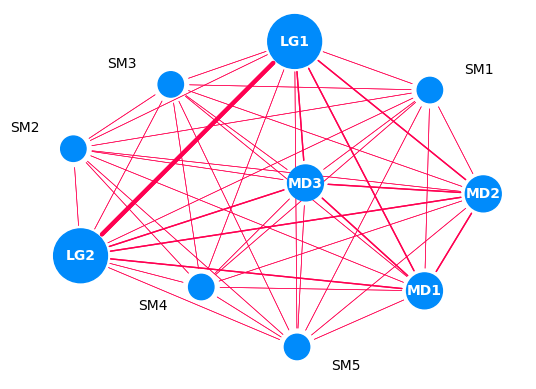

In [ ]:
import os
import sys

from cgt_perezsechi.visualization.graph import draw

node_pos = {
    "SM1": [5, 18],
    "SM2": [0, 9],
    "SM3": [10, 9],
    "SM4": [8, -6],
    "SM5": [2, -6],
    "MD1": [8, 7],
    "MD2": [2, 7],
    "MD3": [5, 1],
    "LG1": [4, 5],
    "LG2": [6, 5],
}

draw(
    psi=psi_2,
    r=r_2,
    positive_alpha=0,
    negative_alpha=0,
    positive_beta=0,
    negative_beta=0,
    symmetric=True,
    layout="spring",
    label_margin=0.11,
    positive_color=positive_color,
    negative_color=negative_color,
    # output_path=os.path.join("..", "..", "results", "airport-0-0-0-0.jpg")
)

####  $\Psi_{\alpha^{+} = 0, \alpha^{-} = 0.25}^{2}; R_{\beta^{+} = 0; \beta^{-} = 0}^{2}$

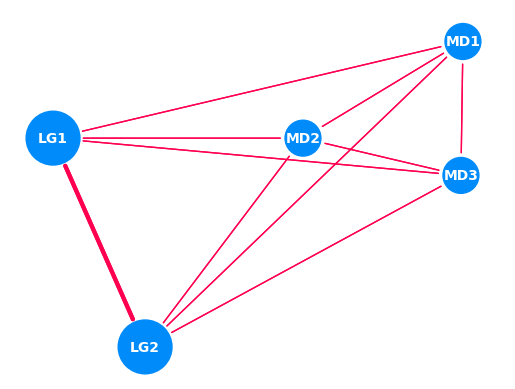

In [ ]:
import os
import sys

from cgt_perezsechi.visualization.graph import draw

draw(
    psi=psi_2,
    r=r_2,
    positive_alpha=0,
    negative_alpha=0.25,
    positive_beta=0,
    negative_beta=0,
    symmetric=True,
    layout=None,
    label_margin=0.15,
    positive_color=positive_color,
    negative_color=negative_color,
    # output_path=os.path.join("..", "..", "results", "airport-0-025-0-0.jpg")
)